In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterio -q

In [ ]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob
import os

# Define the base path
base_path = "/content/drive/MyDrive/Geocoding/Outputs"

# Construct the search pattern
pattern = os.path.join(base_path, "DBH_Predicted_*.tif")

# Retrieve all matching files
dbh_files = glob.glob(pattern)

# Display the found files
print("Found DBH_Predicted_ raster files:")
for file in sorted(dbh_files):
    print(file)


Found DBH_Predicted_ raster files:
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2005 (1).tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2024.tif


In [ ]:
import glob
import os
import re

# Define the base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs"

# Construct the search pattern
pattern = os.path.join(base_path, "H_Predicted_*.tif")

# Filter files: exclude "Masked" and include only those with year ranges (e.g., 2015_2016)
h_files = [
    f for f in glob.glob(pattern)
    if "Masked" not in os.path.basename(f) and re.search(r"H_Predicted_\d{4}_\d{4}\.tif", os.path.basename(f))
]

# Display the filtered files
print("Filtered H_Predicted_ raster files (year ranges only, excluding Masked):")
for file in sorted(h_files):
    print(file)


Filtered H_Predicted_ raster files (year ranges only, excluding Masked):
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1989_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1994_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1999_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2004_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2009_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2014_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2019_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif


In [ ]:
import os
import glob
import rasterio
import numpy as np
import re
from rasterio.warp import reproject, Resampling

# Constants
wood_density = 0.6  # g/cm³
output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB"
os.makedirs(output_dir, exist_ok=True)

# Base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs"

# Gather files
dbh_files = sorted(glob.glob(os.path.join(base_path, "DBH_Predicted_*.tif")))
h_files = sorted(glob.glob(os.path.join(base_path, "H_Predicted_*.tif")))

# Build a dict from H files using both years in the filename as keys
h_dict = {}
for h_path in h_files:
    name = os.path.basename(h_path).replace(".tif", "")
    parts = name.split("_")
    if len(parts) >= 4 and parts[2].isdigit() and parts[3].isdigit():
        year1 = int(parts[2])
        year2 = int(parts[3])
        h_dict[frozenset([year1, year2])] = h_path

# Loop through DBH rasters and find matching H raster
for dbh_path in dbh_files:
    # Extract 4-digit year using regex (handles e.g. "2005 (1)")
    match = re.search(r"DBH_Predicted_(\d{4})", os.path.basename(dbh_path))
    if not match:
        print(f"Skipping invalid DBH filename: {dbh_path}")
        continue

    dbh_year = int(match.group(1))

    matched_h_path = None
    for h_years, h_path in h_dict.items():
        if dbh_year in h_years:
            matched_h_path = h_path
            break

    if not matched_h_path:
        print(f" No H raster for DBH year {dbh_year}")
        continue

    print(f" Matching DBH {dbh_year} → H {os.path.basename(matched_h_path)}")

    # Read rasters
    with rasterio.open(dbh_path) as dbh_src, rasterio.open(matched_h_path) as h_src:
        dbh = dbh_src.read(1)

        # Resample H to match DBH
        h_resampled = np.empty((dbh_src.height, dbh_src.width), dtype=h_src.dtypes[0])
        reproject(
            source=rasterio.band(h_src, 1),
            destination=h_resampled,
            src_transform=h_src.transform,
            src_crs=h_src.crs,
            dst_transform=dbh_src.transform,
            dst_crs=dbh_src.crs,
            resampling=Resampling.bilinear
        )
        h = h_resampled

        # Convert DBH from meters to cm
        dbh_cm = dbh * 100

        # Mask no-data values
        dbh_masked = np.ma.masked_where(dbh == dbh_src.nodata, dbh_cm)
        h_masked = np.ma.masked_where(h == h_src.nodata, h)

        # Apply Chave 2014 AGB equation
        agb = 0.0673 * np.power(wood_density * dbh_masked**2 * h_masked, 0.976)
        agb_filled = agb.filled(-9999)

    # Save result
    out_path = os.path.join(output_dir, f"AGB_Predicted_{dbh_year}.tif")
    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=agb_filled.shape[0],
        width=agb_filled.shape[1],
        count=1,
        dtype="float32",
        crs=dbh_src.crs,
        transform=dbh_src.transform,
        nodata=-9999
    ) as dst:
        dst.write(agb_filled.astype("float32"), 1)

    print(f" Saved: {out_path}\n")


 Matching DBH 1990 → H H_Predicted_1989_1990.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1990.tif

 Matching DBH 1995 → H H_Predicted_1994_1995.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1995.tif

 Matching DBH 2000 → H H_Predicted_1999_2000.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2000.tif

 Matching DBH 2005 → H H_Predicted_2004_2005.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2005.tif

 Matching DBH 2005 → H H_Predicted_2004_2005.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2005.tif

 Matching DBH 2010 → H H_Predicted_2009_2010.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2010.tif

 Matching DBH 2015 → H H_Predicted_2014_2015.tif
 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2015.tif

 Matching DBH 2020 → H H_Predicted_2019_2020.tif

In [ ]:
import os
import glob
import rasterio
import numpy as np
import re
from rasterio.warp import reproject, Resampling

# Constants
wood_density = 0.6  # g/cm³
output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB"
os.makedirs(output_dir, exist_ok=True)

# Base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs"

# Gather files
dbh_files = sorted(glob.glob(os.path.join(base_path, "DBH_Predicted_*.tif")))
h_files = sorted(glob.glob(os.path.join(base_path, "H_Predicted_*.tif")))

# Build a dict from H files using both years in the filename as keys
h_dict = {}
for h_path in h_files:
    name = os.path.basename(h_path).replace(".tif", "")
    parts = name.split("_")
    if len(parts) >= 4 and parts[2].isdigit() and parts[3].isdigit():
        year1 = int(parts[2])
        year2 = int(parts[3])
        h_dict[frozenset([year1, year2])] = h_path

# Loop through DBH rasters and find matching H raster
for dbh_path in dbh_files:
    # Extract 4-digit year using regex
    match = re.search(r"DBH_Predicted_(\d{4})", os.path.basename(dbh_path))
    if not match:
        print(f"Skipping invalid DBH filename: {dbh_path}")
        continue

    dbh_year = int(match.group(1))

    matched_h_path = None
    for h_years, h_path in h_dict.items():
        if dbh_year in h_years:
            matched_h_path = h_path
            break

    if not matched_h_path:
        print(f"❌ No H raster for DBH year {dbh_year}")
        continue

    print(f"✅ Matching DBH {dbh_year} → H {os.path.basename(matched_h_path)}")

    # Read rasters
    with rasterio.open(dbh_path) as dbh_src, rasterio.open(matched_h_path) as h_src:
        dbh = dbh_src.read(1)

        # Resample H to match DBH
        h_resampled = np.empty((dbh_src.height, dbh_src.width), dtype=h_src.dtypes[0])
        reproject(
            source=rasterio.band(h_src, 1),
            destination=h_resampled,
            src_transform=h_src.transform,
            src_crs=h_src.crs,
            dst_transform=dbh_src.transform,
            dst_crs=dbh_src.crs,
            resampling=Resampling.bilinear
        )
        h = h_resampled

        # Convert DBH from meters to cm
        dbh_cm = dbh * 100

        # Mask no-data values
        dbh_masked = np.ma.masked_where(dbh == dbh_src.nodata, dbh_cm)
        h_masked = np.ma.masked_where(h == h_src.nodata, h)

        # Apply Chave 2014 equation: gives AGB in grams
        agb_grams = 0.0673 * np.power(wood_density * dbh_masked**2 * h_masked, 0.976)

        # Calculate pixel area in m² from affine transform
        pixel_area_m2 = abs(dbh_src.transform.a * dbh_src.transform.e)

        # Convert AGB to tons per hectare (t/ha)
        agb_tpha = (agb_grams / 1_000_000) * (10_000 / pixel_area_m2)

        # Fill masked values with nodata
        agb_filled = agb_tpha.filled(-9999)

    # Save result
    out_path = os.path.join(output_dir, f"AGB_Predicted_{dbh_year}_tph.tif")
    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=agb_filled.shape[0],
        width=agb_filled.shape[1],
        count=1,
        dtype="float32",
        crs=dbh_src.crs,
        transform=dbh_src.transform,
        nodata=-9999
    ) as dst:
        dst.write(agb_filled.astype("float32"), 1)

    print(f"💾 Saved: {out_path}\n")


✅ Matching DBH 1990 → H H_Predicted_1989_1990.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1990_tph.tif

✅ Matching DBH 1995 → H H_Predicted_1994_1995.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1995_tph.tif

✅ Matching DBH 2000 → H H_Predicted_1999_2000.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2000_tph.tif

✅ Matching DBH 2005 → H H_Predicted_2004_2005.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2005_tph.tif

✅ Matching DBH 2005 → H H_Predicted_2004_2005.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2005_tph.tif

✅ Matching DBH 2010 → H H_Predicted_2009_2010.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2010_tph.tif

✅ Matching DBH 2015 → H H_Predicted_2014_2015.tif
💾 Saved: /content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2015_tph.tif

✅ Matc

In [ ]:
import glob
import os

agb_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"

# Try both patterns
raster_files = sorted(glob.glob(os.path.join(agb_path, "AGB_Predicted_*.tif")))
print(f" Found {len(raster_files)} raster files matching 'AGB_Predicted_*.tif'")

# Print sample filenames
for f in raster_files[:5]:
    print("   🔹", os.path.basename(f))

# If nothing is found, suggest checking directory
if not raster_files:
    print(" No raster files found. Please check:")
    print("   - Directory path:", agb_path)
    print("   - File name pattern (e.g., AGB_Predicted_2005.tif)")
    print("   - That the Google Drive is mounted and accessible.")


 Found 16 raster files matching 'AGB_Predicted_*.tif'
   🔹 AGB_Predicted_1990.tif
   🔹 AGB_Predicted_1990_tph.tif
   🔹 AGB_Predicted_1995.tif
   🔹 AGB_Predicted_1995_tph.tif
   🔹 AGB_Predicted_2000.tif


 Found 8 raster files


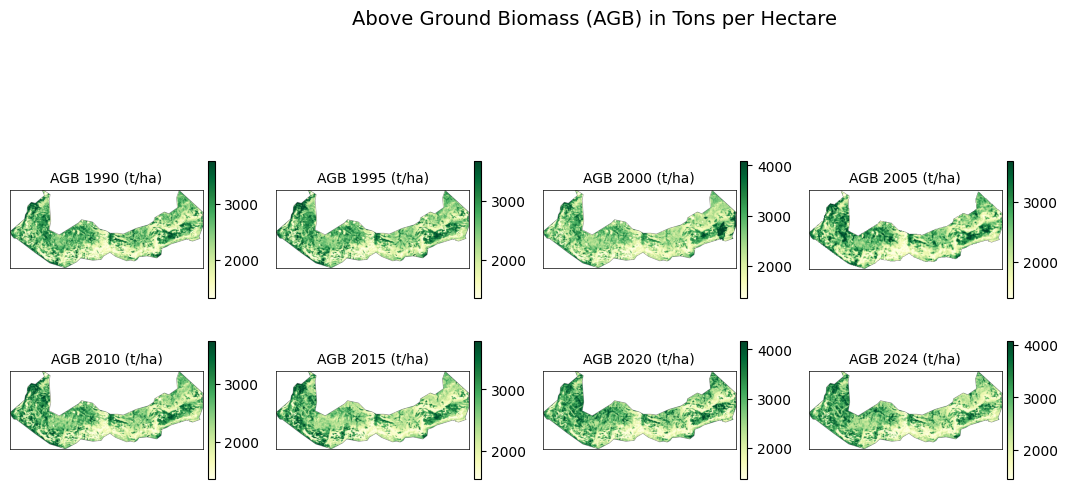

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
from shapely.geometry import mapping
import os
import glob
import re

# Base paths
agb_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Get all AGB raster files
raster_files = sorted(glob.glob(os.path.join(agb_path, "AGB_Predicted_*.tif")))
print(f" Found {len(raster_files)} raster files")

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)
gdf_mask = gdf_mask.to_crs(epsg=21036)

masked_rasters = []

# Process each raster
for raster_path in raster_files:
    try:
        # Extract 4-digit year from filename
        year_match = re.search(r'(\d{4})', os.path.basename(raster_path))
        year = year_match.group(1) if year_match else "Unknown"

        with rasterio.open(raster_path) as src:
            # Reproject mask if needed
            gdf_mask_proj = gdf_mask.to_crs(src.crs)

            out_image, out_transform = rasterio.mask.mask(
                src, [mapping(geom) for geom in gdf_mask_proj.geometry], crop=True
            )
            nodata_value = src.nodata
            masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])
            if masked_data.count() > 0:
                masked_rasters.append((year, masked_data))
            else:
                print(f" All pixels masked in {raster_path}")

    except Exception as e:
        print(f" Failed to process {raster_path}: {e}")

# Plotting
if not masked_rasters:
    print(" No valid raster data to plot.")
else:
    cols = 4
    rows = int(np.ceil(len(masked_rasters) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))

    for idx, (year, data) in enumerate(masked_rasters):
        ax = plt.subplot(rows, cols, idx + 1)
        vmin = np.nanpercentile(data.compressed(), 2)
        vmax = np.nanpercentile(data.compressed(), 98)
        img = ax.imshow(data, cmap="YlGn", vmin=vmin, vmax=vmax)
        ax.set_title(f"AGB {year} (t/ha)", fontsize=10)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        plt.colorbar(img, ax=ax, shrink=0.4, pad=0.02)

    plt.suptitle("Above Ground Biomass (AGB) in Tons per Hectare", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.90, 0.64])
    plt.subplots_adjust(top=0.90)
    plt.show()


In [ ]:
import glob
import os

# Define the base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"

# List all .tif files in the directory
tif_files = glob.glob(os.path.join(base_path, "*.tif"))

# Print the list of files
print("Raster files in AGB directory:")
for file in tif_files:
    print(file)


Raster files in AGB directory:
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2020.tif


In [ ]:
import rasterio
import numpy as np
import pandas as pd

# Prepare a list to store statistics
agb_stats = []

# Loop through each file
for file in tif_files:
    year = os.path.basename(file).split("_")[-1].split(".")[0]  # Extract year

    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        data = np.where(data == nodata, np.nan, data)  # Mask nodata

        # Calculate statistics
        stats = {
            "Year": int(year),
            "Mean_AGB": np.nanmean(data),
            "Min_AGB": np.nanmin(data),
            "Max_AGB": np.nanmax(data),
            "StdDev_AGB": np.nanstd(data),
            "Valid_Pixel_Count": np.count_nonzero(~np.isnan(data))
        }

        agb_stats.append(stats)

# Convert list to DataFrame
df_agb_summary2 = pd.DataFrame(agb_stats).sort_values("Year").reset_index(drop=True)
print(df_agb_summary2)


   Year     Mean_AGB     Min_AGB      Max_AGB  StdDev_AGB  Valid_Pixel_Count
0  1990  2420.523438  674.352478  5551.613770  656.501099             776052
1  1995  2414.941406  653.678772  4961.310059  615.658386             776052
2  2000  2479.617920  679.168945  6444.920898  691.367676             776052
3  2005  1487.580811  435.692139  4692.377930  968.964355              49567
4  2010  2446.501709  629.769775  5552.934082  627.618591             776052
5  2015  1983.257080  974.019775  7097.800781  637.918396            1769588
6  2020  2051.768799  956.240967  7135.595703  758.808594            1769588
7  2024  2026.262085  969.274780  7111.269043  712.782471            1769588


In [ ]:
df_agb_summary2.head(10)

,Year,Mean_AGB,Min_AGB,Max_AGB,StdDev_AGB,Valid_Pixel_Count
0,1990,2420.523438,674.352478,5551.613770,656.501099,776052
1,1995,2414.941406,653.678772,4961.310059,615.658386,776052
2,2000,2479.617920,679.168945,6444.920898,691.367676,776052
3,2005,1487.580811,435.692139,4692.377930,968.964355,49567
4,2010,2446.501709,629.769775,5552.934082,627.618591,776052
5,2015,1983.257080,974.019775,7097.800781,637.918396,1769588
6,2020,2051.768799,956.240967,7135.595703,758.808594,1769588
7,2024,2026.262085,969.274780,7111.269043,712.782471,1769588


In [ ]:
df= df_agb_summary2

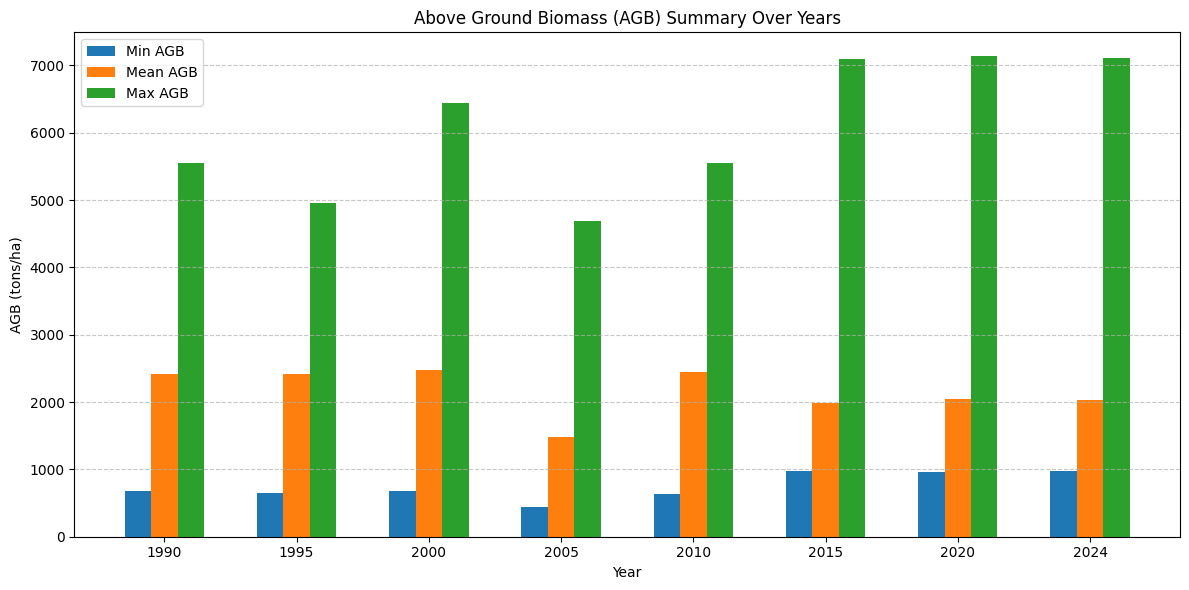

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Set position of bar on X axis
bar_width = 0.2
years = df["Year"].astype(str)
x = np.arange(len(years))

# Plot grouped bars
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width, df["Min_AGB"], width=bar_width, label="Min AGB")
plt.bar(x, df["Mean_AGB"], width=bar_width, label="Mean AGB")
plt.bar(x + bar_width, df["Max_AGB"], width=bar_width, label="Max AGB")

# Add labels and formatting
plt.xlabel("Year")
plt.ylabel("AGB (tons/ha)")
plt.title("Above Ground Biomass (AGB) Summary Over Years")
plt.xticks(x, years)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
raster_files = sorted(glob.glob(os.path.join(agb_path, "AGB_Predicted_*_tph.tif")))


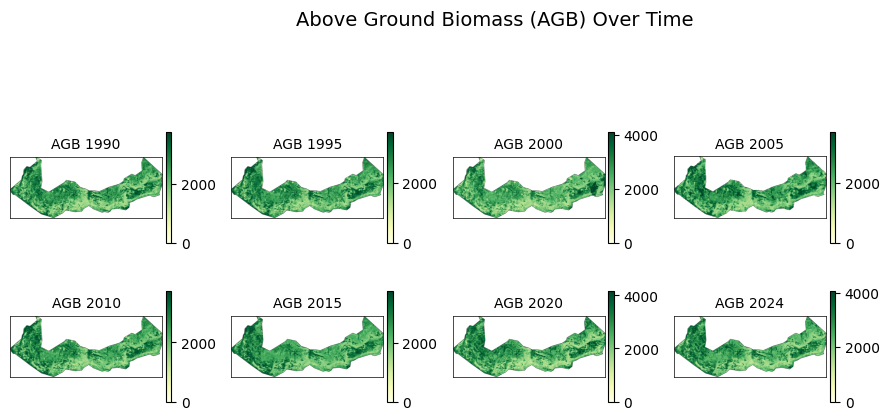

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import os
import glob

# Base paths
agb_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Get all AGB raster files
raster_files = sorted(glob.glob(os.path.join(agb_path, "AGB_Predicted_*.tif")))

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)
# Reproject to match raster CRS
gdf_mask = gdf_mask.to_crs(epsg=21036)
masked_rasters = []

# Process each raster
for raster_path in raster_files:
    try:
        year = os.path.basename(raster_path).split("_")[-1].replace(".tif", "")
        with rasterio.open(raster_path) as src:
            out_image, out_transform = rasterio.mask.mask(
                src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
            nodata_value = src.nodata
            masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])
            masked_rasters.append((year, masked_data))
    except Exception as e:
        print(f"Failed to process {raster_path}: {e}")

# --- PLOTTING ---
cols = 4
rows = int(np.ceil(len(masked_rasters) / cols))
plt.figure(figsize=(cols * 2.5, rows * 2.5))

for idx, (year, data) in enumerate(masked_rasters):
    ax = plt.subplot(rows, cols, idx + 1)
    img = ax.imshow(data, cmap="YlGn", vmin=0, vmax=np.nanpercentile(data.compressed(), 98))
    ax.set_title(f"AGB {year}", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(img, ax=ax, shrink=0.4, pad=0.02)

plt.suptitle("Above Ground Biomass (AGB) Over Time", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.90, 0.64])
plt.subplots_adjust(top=0.90)
plt.show()


**Allometric Biomass Summary Statistics**

In [ ]:
import glob
import os

# Define the base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB"

# List all .tif files in the directory
tif_files = glob.glob(os.path.join(base_path, "*.tif"))

# Print the list of files
print("Raster files in AGB directory:")
for file in tif_files:
    print(file)


Raster files in AGB directory:
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/AGB_Predicted_2020.tif


In [ ]:
import rasterio
import numpy as np
import pandas as pd
import os

# Filter tif_files to exclude those with 'tph' in the filename
filtered_tif_files = [f for f in tif_files if "tph" not in os.path.basename(f).lower()]

# Prepare a list to store statistics
agb_stats = []

# Loop through each filtered file
for file in filtered_tif_files:
    year = os.path.basename(file).split("_")[-1].split(".")[0]  # Extract year

    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        data = np.where(data == nodata, np.nan, data)  # Mask nodata

        # Calculate statistics
        stats = {
            "Year": int(year),
            "Mean_AGB": np.nanmean(data),
            "Min_AGB": np.nanmin(data),
            "Max_AGB": np.nanmax(data),
            "StdDev_AGB": np.nanstd(data),
            "Valid_Pixel_Count": np.count_nonzero(~np.isnan(data))
        }

        agb_stats.append(stats)

# Convert list to DataFrame
df_agb_summary = pd.DataFrame(agb_stats).sort_values("Year").reset_index(drop=True)
print(df_agb_summary)


   Year     Mean_AGB     Min_AGB      Max_AGB  StdDev_AGB  Valid_Pixel_Count
0  1990  2420.425293  650.080872  5551.613770  666.710938             779580
1  1995  2414.796143  633.147095  4990.023926  624.547241             779580
2  2000  2479.636963  625.988403  6445.845703  700.745789             779580
3  2005  1486.244751  344.953339  4871.077637  991.993774              49907
4  2010  2446.349854  592.158569  5552.934082  636.589478             779580
5  2015  1983.270020  955.920410  7487.603027  649.643311            1777739
6  2020  2051.786377  952.015198  7487.603027  769.822021            1777739
7  2024  2026.276733  953.094116  7487.603027  724.193848            1777739


In [ ]:
df_agb_summary.tail()

,Year,Mean_AGB,Min_AGB,Max_AGB,StdDev_AGB,Valid_Pixel_Count
3,2005,1486.244751,344.953339,4871.077637,991.993774,49907
4,2010,2446.349854,592.158569,5552.934082,636.589478,779580
5,2015,1983.270020,955.920410,7487.603027,649.643311,1777739
6,2020,2051.786377,952.015198,7487.603027,769.822021,1777739
7,2024,2026.276733,953.094116,7487.603027,724.193848,1777739


In [ ]:
df = df_agb_summary

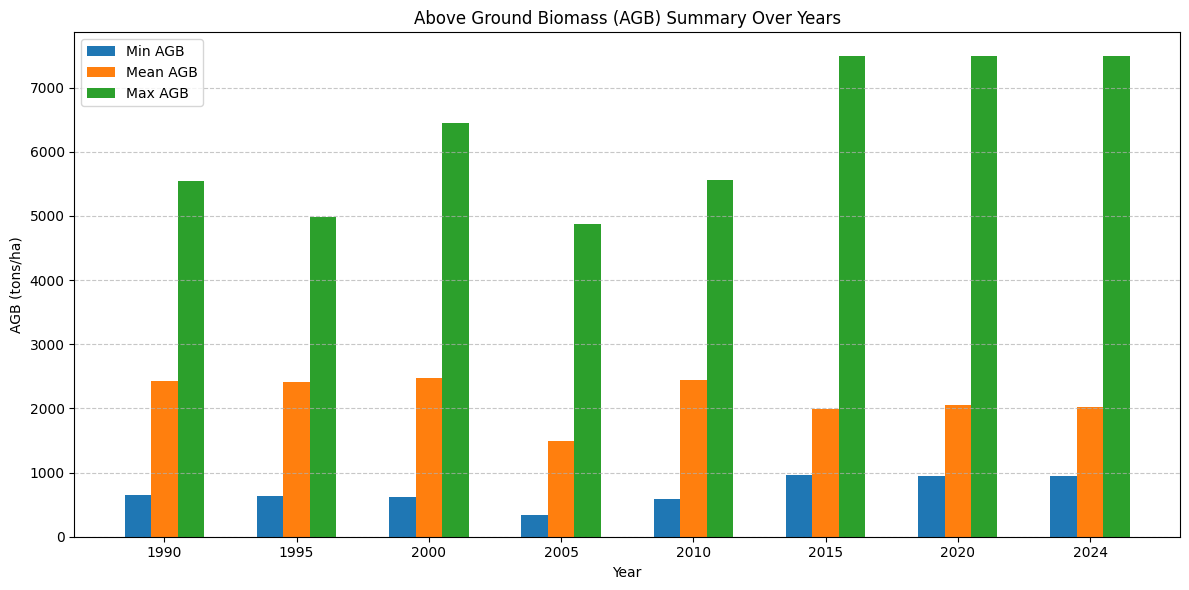

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Set position of bar on X axis
bar_width = 0.2
years = df["Year"].astype(str)
x = np.arange(len(years))

# Plot grouped bars
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width, df["Min_AGB"], width=bar_width, label="Min AGB")
plt.bar(x, df["Mean_AGB"], width=bar_width, label="Mean AGB")
plt.bar(x + bar_width, df["Max_AGB"], width=bar_width, label="Max AGB")

# Add labels and formatting
plt.xlabel("Year")
plt.ylabel("AGB (tons/ha)")
plt.title("Above Ground Biomass (AGB) Summary Over Years")
plt.xticks(x, years)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


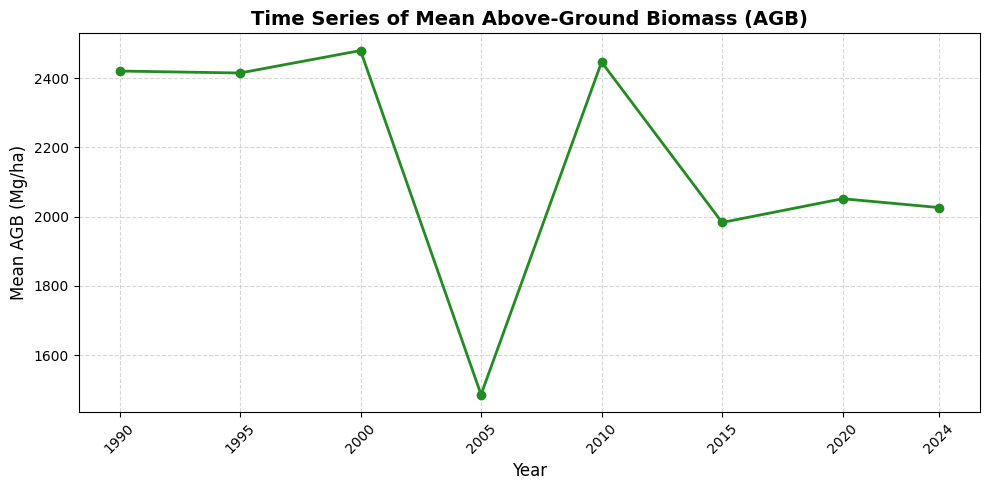

In [ ]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_agb_summary['Year'], df_agb_summary['Mean_AGB'], marker='o', linestyle='-', color='forestgreen', linewidth=2)

# Formatting
plt.title('Time Series of Mean Above-Ground Biomass (AGB)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean AGB (Mg/ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_agb_summary['Year'], rotation=45)
plt.tight_layout()

# Show plot
plt.show()


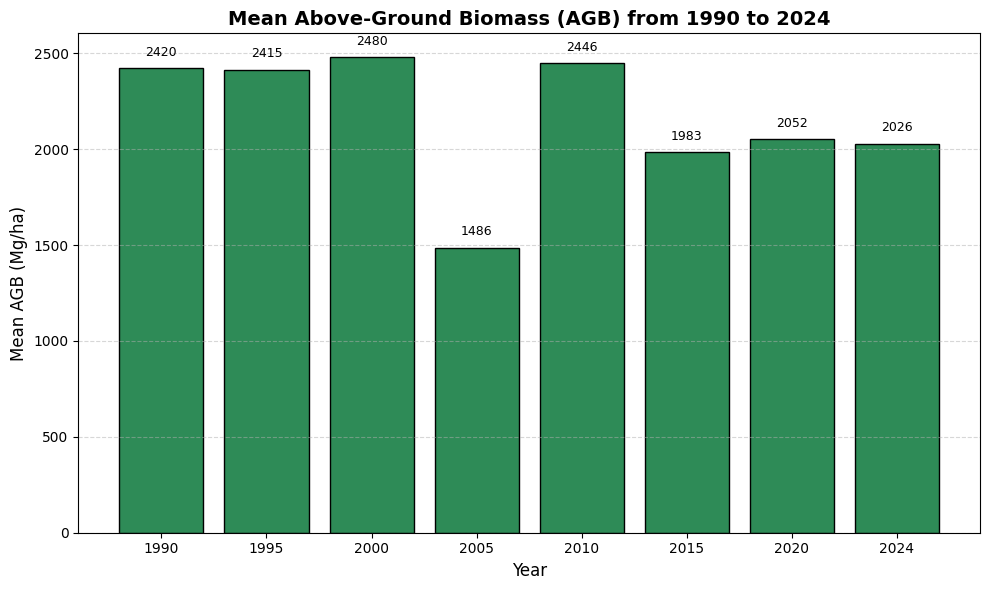

In [ ]:
import matplotlib.pyplot as plt

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(df_agb_summary['Year'].astype(str), df_agb_summary['Mean_AGB'], color='seagreen', edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval:.0f}', ha='center', va='bottom', fontsize=9)

# Formatting
plt.title('Mean Above-Ground Biomass (AGB) from 1990 to 2024', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean AGB (Mg/ha)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
import rasterio
import os

# Path to one of your AGB rasters (example: 1990)
agb_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_1990.tif"

with rasterio.open(agb_path) as src:
    transform = src.transform
    pixel_width = transform.a      # pixel size in X direction
    pixel_height = -transform.e    # pixel size in Y direction (make positive)
    crs = src.crs
    res = src.res                  # tuple (width, height)

print(f"CRS: {crs}")
print(f"Pixel size: {pixel_width} x {pixel_height} meters")


CRS: EPSG:21036
Pixel size: 4.995865596723181 x 4.995865596723181 meters


In [ ]:
import os
import glob
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling as ResampleEnum

# Define input and output directories
input_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB"
output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"
os.makedirs(output_dir, exist_ok=True)

# Target CRS: Arc 1960 / UTM zone 36N (EPSG:21036)
target_crs = "EPSG:21036"

# Gather input files
agb_files = glob.glob(os.path.join(input_dir, "AGB_Predicted_*.tif"))

# Reproject each raster
reprojected_files = []
for file_path in agb_files:
    with rasterio.open(file_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Output path
        filename = os.path.basename(file_path)
        out_path = os.path.join(output_dir, filename)

        with rasterio.open(out_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=ResampleEnum.bilinear
                )

        reprojected_files.append(out_path)

reprojected_files[:3]  # Show a few sample paths to confirm completion


['/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_1990.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_2000.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected/AGB_Predicted_1995.tif']

In [ ]:
import os
import glob
import rasterio
import numpy as np

# Input and output paths
agb_reprojected_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/Reprojected"
carbon_output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock"
os.makedirs(carbon_output_path, exist_ok=True)

# Constants
PIXEL_AREA_M2 = 25  # 5m x 5m pixel
CARBON_FRACTION = 0.47  # IPCC recommended default
KG_TO_MG = 1 / 1000  # Convert kg to Mg
M2_TO_HA = 10000 / PIXEL_AREA_M2  # Pixels per hectare

# Conversion factor from kg/pixel to tC/ha
CONVERSION_FACTOR = KG_TO_MG * M2_TO_HA * CARBON_FRACTION

# Process each reprojected AGB raster
carbon_rasters = []
agb_files = sorted(glob.glob(os.path.join(agb_reprojected_path, "AGB_Predicted_*.tif")))
for agb_file in agb_files:
    with rasterio.open(agb_file) as src:
        agb_data = src.read(1)
        meta = src.meta.copy()

        # Mask nodata values
        agb_masked = np.ma.masked_equal(agb_data, src.nodata)

        # Convert AGB to Carbon Stock (Mg/ha)
        carbon_data = agb_masked * CONVERSION_FACTOR
        carbon_filled = carbon_data.filled(src.nodata)

        # Output file path
        filename = os.path.basename(agb_file).replace("AGB", "CarbonStock")
        out_path = os.path.join(carbon_output_path, filename)

        # Save
        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(carbon_filled.astype("float32"), 1)

        carbon_rasters.append(out_path)

carbon_rasters  # List of saved carbon stock rasters (tC/ha)


['/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1990.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1995.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2000.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2005.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2010.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2015.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2020.tif',
 '/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2024.tif']

In [ ]:
import geopandas as gpd

mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
gdf_mask = gpd.read_file(mask_path)

# Reproject to match raster CRS
gdf_mask = gdf_mask.to_crs(epsg=21036)


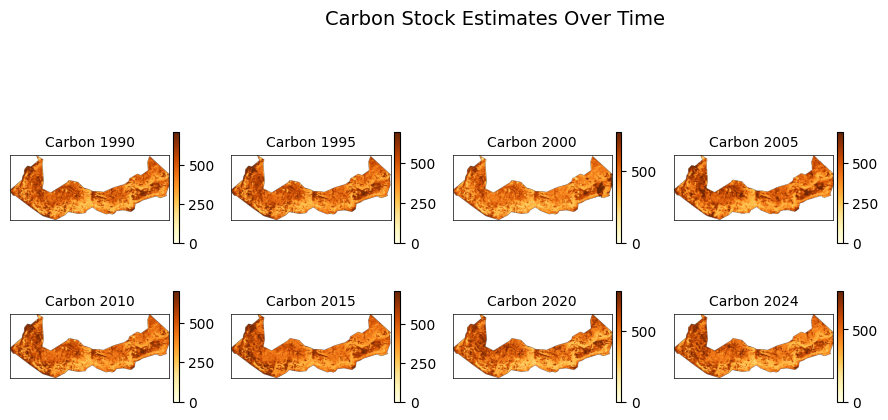

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
from shapely.geometry import mapping
import os
import glob

# Define paths
agb_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Get all raster files
raster_files = sorted(glob.glob(os.path.join(agb_path, "*.tif")))

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)
# Reproject to match raster CRS
gdf_mask = gdf_mask.to_crs(epsg=21036)
masked_rasters = []

# Mask and collect raster data
for raster_path in raster_files:
    try:
        year = os.path.basename(raster_path).split("_")[-1].replace(".tif", "")
        with rasterio.open(raster_path) as src:
            out_image, out_transform = rasterio.mask.mask(
                src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
            nodata_value = src.nodata
            masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])
            masked_rasters.append((year, masked_data))
    except Exception as e:
        print(f"Failed to process {raster_path}: {e}")

# Plotting
cols = 4
rows = int(np.ceil(len(masked_rasters) / cols))
plt.figure(figsize=(cols * 2.5, rows * 2.5))

for idx, (year, data) in enumerate(masked_rasters):
    ax = plt.subplot(rows, cols, idx + 1)
    img = ax.imshow(data, cmap="YlOrBr", vmin=0, vmax=np.nanpercentile(data.compressed(), 98))
    ax.set_title(f"Carbon {year}", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(img, ax=ax, shrink=0.4, pad=0.02)

plt.suptitle("Carbon Stock Estimates Over Time", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.90, 0.64])
plt.subplots_adjust(top=0.90)
plt.show()


In [ ]:
import glob
import os

# Define the base path
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock"

# List all .tif files in the directory
tif_files = glob.glob(os.path.join(base_path, "*.tif"))

# Print the list of files
print("Raster files in AGB directory:")
for file in tif_files:
    print(file)


Raster files in AGB directory:
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1990_tph.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CarbonStock/CarbonStock_Predicted_1995_tph.tif
/content/drive/MyDriv

In [ ]:
import rasterio
import numpy as np
import pandas as pd
import os

# Exclude files with 'tph' in the filename
filtered_tif_files = [f for f in tif_files if "tph" not in os.path.basename(f).lower()]

# Prepare a list to store statistics
co2_stats = []

# Loop through each valid file
for file in filtered_tif_files:
    year = os.path.basename(file).split("_")[-1].split(".")[0]  # Extract year

    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        data = np.where(data == nodata, np.nan, data)  # Mask nodata

        # Calculate statistics
        stats = {
            "Year": int(year),
            "Mean_CO2": np.nanmean(data),
            "Min_CO2": np.nanmin(data),
            "Max_CO2": np.nanmax(data),
            "StdDev_CO2": np.nanstd(data),
            "Valid_Pixel_Count": np.count_nonzero(~np.isnan(data))
        }

        co2_stats.append(stats)

# Convert list to DataFrame
df_agb_summarycab = pd.DataFrame(co2_stats).sort_values("Year").reset_index(drop=True)
print(df_agb_summarycab)


   Year    Mean_CO2     Min_CO2      Max_CO2  StdDev_CO2  Valid_Pixel_Count
0  1990  455.058258  126.778267  1043.703369  123.422180             776052
1  1995  454.009277  122.891609   932.726318  115.743782             776052
2  2000  466.168182  127.683762  1211.645142  129.977127             776052
3  2005  279.665161   81.910126   882.167053  182.165298              49567
4  2010  459.942322  118.396721  1043.951660  117.992363             776052
5  2015  372.852112  183.115723  1334.386597  119.928673            1769588
6  2020  385.732269  179.773300  1341.491943  142.656036            1769588
7  2024  380.937256  182.223663  1336.918579  134.003113            1769588


In [ ]:
df=df_agb_summarycab

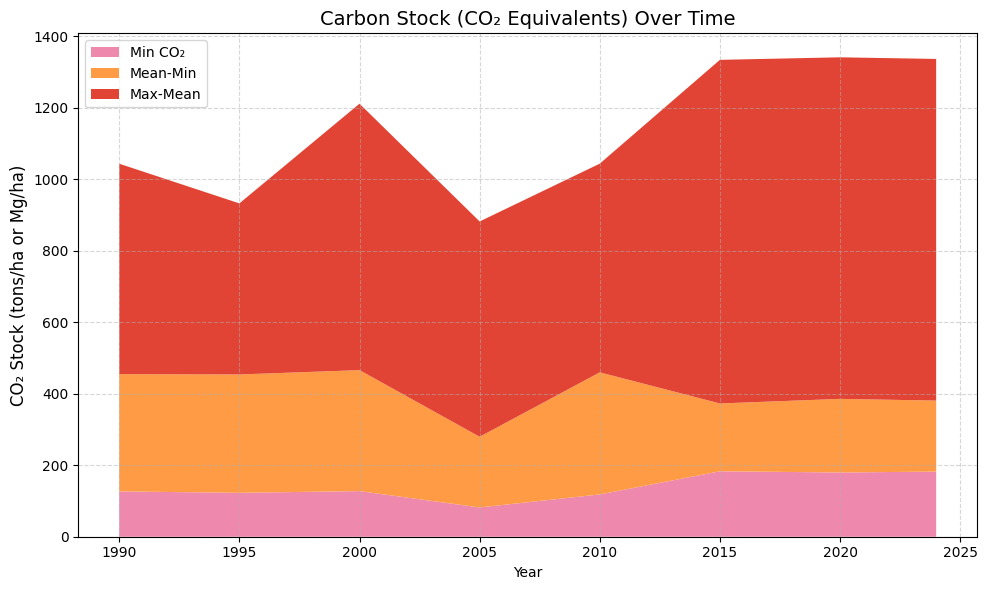

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Calculate lower and upper bands for stacking
min_band = df["Min_CO2"]
mid_band = df["Mean_CO2"] - df["Min_CO2"]
top_band = df["Max_CO2"] - df["Mean_CO2"]

# Plot stacked area
plt.figure(figsize=(10, 6))
plt.stackplot(
    df["Year"],
    min_band,
    mid_band,
    top_band,
    labels=["Min CO₂", "Mean-Min", "Max-Mean"],
    colors = ["#EF88AD", "#FF9B45", "#E14434"]  # light red, medium red, dark red
)

# Customize plot
plt.title("Carbon Stock (CO₂ Equivalents) Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("CO₂ Stock (tons/ha or Mg/ha)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


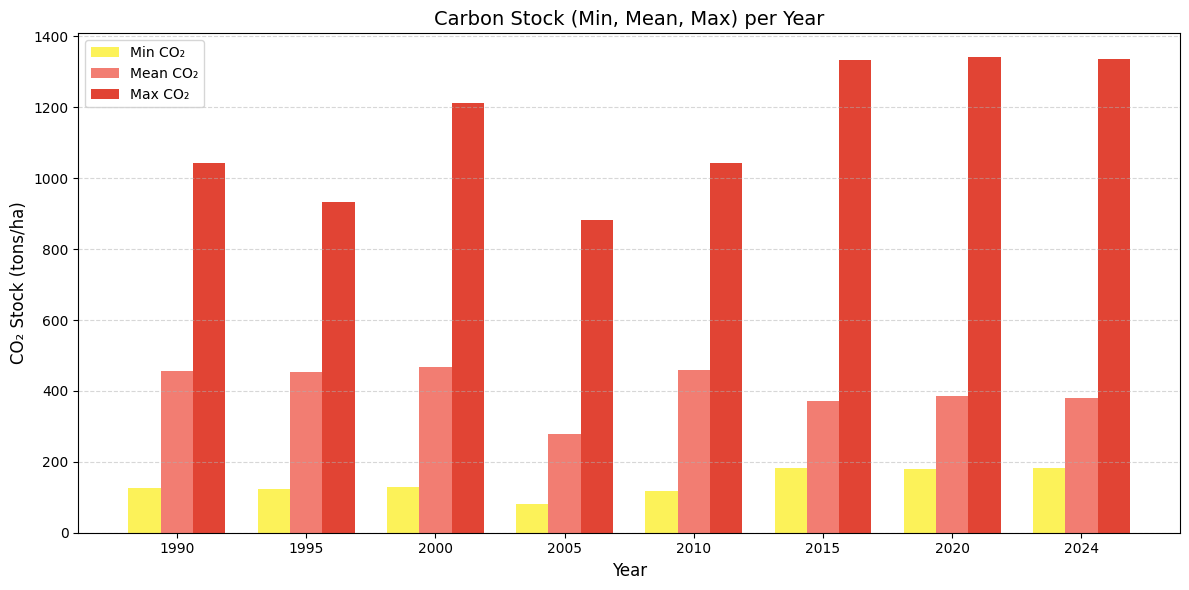

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Setup for grouped bar plot
years = df["Year"]
x = np.arange(len(years))  # x locations
width = 0.25  # bar width

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width, df["Min_CO2"], width=width, label='Min CO₂', color='#FCF259')
plt.bar(x, df["Mean_CO2"], width=width, label='Mean CO₂', color='#f27d72')
plt.bar(x + width, df["Max_CO2"], width=width, label='Max CO₂', color='#E14434')

# Labels and formatting
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ Stock (tons/ha)", fontsize=12)
plt.title("Carbon Stock (Min, Mean, Max) per Year", fontsize=14)
plt.xticks(x, years)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential val

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)
